# 05 · Bayes by Simulation

**Session 6 · Sat Sep 26 · 1.5 hours (stats half)**

> **This is the most important notebook in the set.** Not the hardest — the most *consequential*.
> The idea in it is the one that most reliably breaks trained professionals' intuition, it underpins
> every discussion of model accuracy you will have in your career, and it is the technical reason a
> "95% accurate" AI system can still be unfit to deploy.

We will not start from the formula. We will start from 50,000 transactions and just **count**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data"
rng = np.random.default_rng(42)   # same seed => same numbers every time you run this

## 1 · The setup

You own a fraud detection model. Here are its specs, and they are genuinely good:

- **Recall (sensitivity): 96%** — it catches 96% of actual fraud.
- **Specificity: 97%** — it correctly clears 97% of legitimate transactions.
- **Base rate: 0.3%** — 3 transactions in 1,000 are actually fraudulent.

The model fires an alert on a transaction. **Before computing anything, write down your gut estimate:
what is the probability this transaction is really fraud?**

Most people say something in the 80–95% range. Let's count.

In [2]:
fraud = pd.read_csv(DATA / "fraud_alerts.csv")
print(f"transactions: {len(fraud):,}")
fraud.head()

transactions: 50,000


,txn_id,amount,is_fraud,model_alert
0,TX0000000,45.96,0,0
1,TX0000001,34.40,0,0
2,TX0000002,85.28,0,0
3,TX0000003,13.73,0,0
4,TX0000004,22.33,0,0


In [3]:
# The 2x2 table. Everything in evaluation comes from these four numbers.
ct = pd.crosstab(fraud.is_fraud, fraud.model_alert,
                 rownames=["actually fraud"], colnames=["model alerted"])
print(ct)

TN, FP = ct.loc[0, 0], ct.loc[0, 1]
FN, TP = ct.loc[1, 0], ct.loc[1, 1]
print(f"\nTrue  Positives (caught fraud):        {TP:>6,}")
print(f"False Positives (false alarms):        {FP:>6,}")
print(f"False Negatives (missed fraud):        {FN:>6,}")
print(f"True  Negatives (correctly cleared):   {TN:>6,}")

model alerted       0     1
actually fraud             
0               48342  1503
1                   5   150

True  Positives (caught fraud):           150
False Positives (false alarms):         1,503
False Negatives (missed fraud):             5
True  Negatives (correctly cleared):   48,342


## 2 · The answer

`P(fraud | alert)` is, by the definition you learned in notebook 04, a **filter**: among all the rows
where the model alerted, what fraction were actually fraud?

In [4]:
alerted = fraud[fraud.model_alert == 1]
precision = (alerted.is_fraud == 1).mean()

print(f"the model alerted on {len(alerted):,} transactions")
print(f"of those, {(alerted.is_fraud==1).sum():,} were really fraud")
print()
print(f"P(fraud | alert) = {precision:.1%}")
print()
print(f"...and for contrast, recall  P(alert | fraud) = {TP/(TP+FN):.1%}")

the model alerted on 1,653 transactions
of those, 150 were really fraud

P(fraud | alert) = 9.1%

...and for contrast, recall  P(alert | fraud) = 96.8%


## 3 · Sit with that for a minute

**9% — not 96%.**

The model is exactly as good as advertised. It catches 96.8% of fraud. And yet **more than nine out
of ten of its alerts are false alarms.**

Nothing is broken. The explanation is arithmetic, and it is entirely about how rare fraud is:

- Fraud is 0.3% of 50,000 transactions ≈ **155 fraudulent** transactions. The model catches ~150.
- Legitimate transactions are the other ~49,845. The model wrongly flags 3% of them — and 3% of
  49,845 is about **1,500 false alarms.**

150 real against 1,500 false. The false positives come from a pool 300 times larger, so even a small
error rate on that huge pool swamps the true positives entirely.

### The two probabilities you must never swap

| Expression | Reads as | Value here |
|---|---|---|
| `P(alert \| fraud)` | "of real fraud, how much do we catch?" | **96.8%** — recall |
| `P(fraud \| alert)` | "of our alerts, how many are real?" | **9.1%** — precision |

Same model. Same data. The two numbers differ by a factor of ten, and the only difference is which
side of the pipe each event sits on. Confusing them is called the **base-rate fallacy**, and it is
the most expensive statistical error in commercial practice.

## 4 · The formula, now that you already know the answer

Bayes' theorem is just the bookkeeping for what you counted above:

$$P(A \mid B) = \frac{P(B \mid A)\;P(A)}{P(B)}$$

In our terms:

$$P(\text{fraud} \mid \text{alert}) = \frac{P(\text{alert} \mid \text{fraud}) \times P(\text{fraud})}{P(\text{alert})}$$

Read it as a sentence: *take how often fraud triggers an alert, weight it by how common fraud is, and
divide by how often alerts happen at all.* The `P(A)` in the numerator is the base rate — the term
people's intuition silently drops, which is exactly where the error comes from.

In [5]:
p_fraud       = fraud.is_fraud.mean()
p_alert_fraud = TP / (TP + FN)
p_alert       = fraud.model_alert.mean()

bayes = (p_alert_fraud * p_fraud) / p_alert

print(f"P(alert | fraud) = {p_alert_fraud:.4f}")
print(f"P(fraud)         = {p_fraud:.4f}      <- the base rate; the term intuition forgets")
print(f"P(alert)         = {p_alert:.4f}")
print()
print(f"Bayes says:  {bayes:.4f}  ({bayes:.1%})")
print(f"Counting said: {precision:.4f}  ({precision:.1%})")
print()
print("Identical. The formula is a shortcut for the counting -- not a separate idea.")

P(alert | fraud) = 0.9677
P(fraud)         = 0.0031      <- the base rate; the term intuition forgets
P(alert)         = 0.0331

Bayes says:  0.0907  (9.1%)
Counting said: 0.0907  (9.1%)

Identical. The formula is a shortcut for the counting -- not a separate idea.


## 5 · Base rate is destiny

Hold the model completely fixed and vary only how common fraud is.

base rate P(fraud | alert)
    0.01%             0.3%
    0.10%             3.1%
    0.30%             8.8%
    1.00%            24.4%
    5.00%            62.7%
   20.00%            88.9%
   50.00%            97.0%


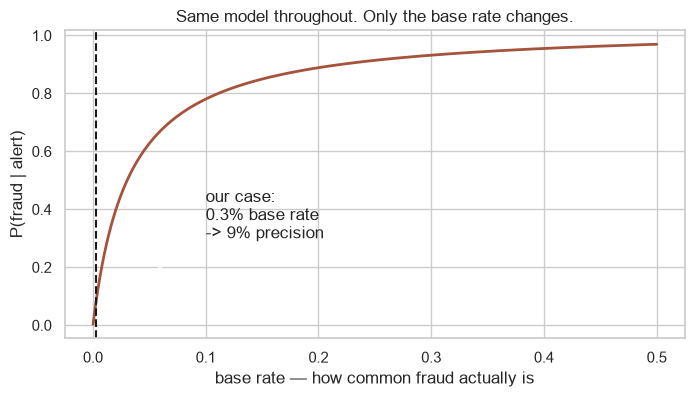

In [6]:
sens, spec = 0.96, 0.97
rates = np.array([0.0001, 0.001, 0.003, 0.01, 0.05, 0.20, 0.50])

rows = []
for r in rates:
    ppv = (sens * r) / (sens * r + (1 - spec) * (1 - r))
    rows.append({"base rate": f"{r:.2%}", "P(fraud | alert)": f"{ppv:.1%}"})
print(pd.DataFrame(rows).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
grid = np.linspace(0.0001, 0.5, 500)
ax.plot(grid, (sens*grid)/(sens*grid + (1-spec)*(1-grid)), lw=2, color="#a5533b")
ax.axvline(0.003, ls="--", color="k")
ax.annotate("our case:\n0.3% base rate\n-> 9% precision", xy=(0.003, .09),
            xytext=(0.10, .30), arrowprops=dict(arrowstyle="->"))
ax.set_xlabel("base rate — how common fraud actually is")
ax.set_ylabel("P(fraud | alert)")
ax.set_title("Same model throughout. Only the base rate changes.")
plt.show()

**The model never changed.** Its precision ranges from 0.3% to 97% depending purely on how common the
thing it looks for is.

This is why "our model is 96% accurate" is close to meaningless as a claim, and why you should always
ask "on what base rate?" It is also why rare-event detection — fraud, disease screening, insider
threat, money laundering — is fundamentally harder than it looks, no matter how good the classifier.

## 6 · Why this matters in PhDAI 832

Keep this notebook. You will reuse it in the ethics course, because the base-rate problem is where
statistics and fairness meet:

1. **"High accuracy" is not a defence.** A model can be accurate and still produce a caseload that is
   overwhelmingly false accusations. If an alert triggers an account freeze or an investigation, then
   a 9% precision model is inflicting harm on 10 innocent people for every guilty one it finds.
2. **Base rates differ across groups.** If the flagged behaviour is more common in one group than
   another, then *identical* model performance yields *different* precision for each group
   automatically. Equal treatment by the algorithm produces unequal experience of it.
3. **This is the engine of the impossibility result.** You will meet the formal statement — that
   demographic parity, equalized odds and calibration cannot generally all hold at once — in your
   ethics reading. The reason is the arithmetic in this notebook. When base rates differ between
   groups, equalizing one fairness measure necessarily unbalances another.

The COMPAS recidivism debate, the most-cited case in AI ethics, is *precisely* this argument:
ProPublica measured one thing (error rates by race), Northpointe measured another (calibration by
race), both were correct, and both could not be equalized simultaneously because base rates differed.

## Your turn

**Exercise 1.** A medical screening test has 99% sensitivity and 99% specificity — better than our
fraud model on both counts. The disease affects 1 in 10,000 people. A patient tests positive. What is
the probability they have the disease? Compute it two ways: by simulating 1,000,000 people, and with
Bayes' formula.

In [7]:
# your code here

In [ ]:
n = 1_000_000
has = rng.binomial(1, 1/10_000, n)
pos = np.where(has == 1, rng.binomial(1, 0.99, n), rng.binomial(1, 0.01, n))

print(f"simulated P(disease | positive) = {has[pos==1].mean():.2%}")

p_d, sens, spec = 1/10_000, 0.99, 0.99
print(f"Bayes     P(disease | positive) = "
      f"{(sens*p_d)/(sens*p_d + (1-spec)*(1-p_d)):.2%}")

# About 1%. A 99%/99% test, and a positive result STILL means you almost certainly
# do not have the disease -- because 100 healthy false positives swamp the 1 true case.
# This is why screening programs confirm with a second, different test.

**Exercise 2.** For the fraud model, how high would specificity need to go to reach 50% precision at
the same 0.3% base rate? (Try values, or solve it.)

In [9]:
# your code here

In [ ]:
r, sens = 0.003, 0.96
for spec in [0.97, 0.99, 0.995, 0.999, 0.9971]:
    ppv = (sens*r)/(sens*r + (1-spec)*(1-r))
    print(f"specificity {spec:.4f} -> precision {ppv:.1%}")

# Solving: precision 0.5 needs (1-spec)(1-r) = sens*r, so
fp_rate = sens*r/(1-r)
print(f"\nneed specificity = {1-fp_rate:.4%}")
# ~99.71%. To halve your false alarms you must cut the false positive rate from 3%
# to 0.29% -- a tenfold improvement -- just to get to a coin flip. THAT is how punishing
# a low base rate is.

## What you did today

- Discovered that a 96%-recall model can have **9% precision**, by counting rather than being told.
- Learned that `P(A|B)` and `P(B|A)` are different numbers, and that swapping them is the base-rate fallacy.
- Derived Bayes' theorem as bookkeeping for something you had already computed.
- Saw that **precision is a property of the base rate as much as of the model.**
- Got the technical foundation for the fairness impossibility result in PhDAI 832.

**Next:** `06_expectation_variance.ipynb`.